<a href="https://colab.research.google.com/github/S-Lamsiah/Heavy-Metal-Adsorption-Activated-Carbon-ML/blob/main/Copie_de_HeavyMetalAdsorptionPredictor_S_Lamsiah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Heavy Metal Adsorption by Activated Carbon Using Machine Learning

**Authors:**  
Said Lamsiah, Mouhcine Benhadj, Imad Alouiz, Mohamed Bouhadda, Mohamed Yassine Amarouch, Driss Mazouzi, Mohamed Sennoune

**Affiliation:**  
 RNE Laboratory, Polydisciplinary Faculty of Taza, University Sidi Mohamed Ben Abdellah, B.P 1223 Taza Gare Taza, Morocco  

This notebook implements the method described in the paper.

In [ ]:
# 1. Importing the necessary libraries

from sklearn.model_selection import KFold, ParameterGrid
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold, StratifiedShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, explained_variance_score)
#from sklearn.metrics import r2_score
#from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import PartialDependenceDisplay
import math
import shap


In [ ]:
# 2. Importing experimental data
from google.colab import files
uploaded = files.upload()

Saving Dataset. S.Lamsiah.xlsx to Dataset. S.Lamsiah.xlsx


In [ ]:
# 3. Reading and initial exploration of the data
data=pd.read_excel('Dataset. S.Lamsiah.xlsx')
data.columns

Index(['ID', 'Reference', 'Year', 'Adsorbent', 'Source of the adsorbent',
       'Adsorbent code', 'Heavy metal', 'Activation temperature (°C)',
       'Hydrated radius (nm)', 'Electronegativity (Pauling)',
       'van der Waals radius (nm)', 'Molar mass (g/mol)',
       'BET surface area (m²/g)', 'Pore diameter (nm)',
       'Total pore volume (cm³/g)\n', 'Temperature (°C)', 'pH', 'Dose (g/L)',
       'Contact time (min)', 'Initial concentration (mg/L)',
       'Adsorption capacity (mg/g)'],
      dtype='object')

In [ ]:
# 4. Detection of missing values
missing_values = data.isnull().sum()
print(missing_values)

ID                              0
Reference                       0
Year                            0
Adsorbent                       0
Source of the adsorbent         0
Adsorbent code                  0
Heavy metal                     0
Activation temperature (°C)     0
Hydrated radius (nm)            0
Electronegativity (Pauling)     0
van der Waals radius (nm)       0
Molar mass (g/mol)              0
BET surface area (m²/g)         0
Pore diameter (nm)              0
Total pore volume (cm³/g)\n     0
Temperature (°C)                0
pH                              0
Dose (g/L)                      0
Contact time (min)              0
Initial concentration (mg/L)    0
Adsorption capacity (mg/g)      0
dtype: int64


In [ ]:
# 5. Descriptive data analysis
data.describe()

,ID,Year,Activation temperature (°C),Hydrated radius (nm),Electronegativity (Pauling),van der Waals radius (nm),Molar mass (g/mol),BET surface area (m²/g),Pore diameter (nm),Total pore volume (cm³/g)\n,Temperature (°C),pH,Dose (g/L),Contact time (min),Initial concentration (mg/L),Adsorption capacity (mg/g)
count,1528.00000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000,1528.000000
mean,764.50000,2017.078534,548.314791,0.404168,1.947205,0.194236,117.829188,899.886874,2.258574,0.581309,27.004581,5.149228,2.045190,94.406741,62.355144,25.919248
std,441.23992,4.850791,153.720154,0.039987,0.292009,0.033299,66.043534,405.898688,0.964283,0.316841,5.284999,1.502050,1.548264,85.314751,44.823706,21.617289
min,1.00000,2008.000000,160.000000,0.200000,1.650000,0.139000,52.000000,9.810000,0.360000,0.010000,10.000000,2.000000,0.200000,2.000000,5.000000,0.151959
25%,382.75000,2013.000000,450.000000,0.401000,1.660000,0.163000,58.690000,676.000000,1.916000,0.418000,25.000000,5.000000,1.000000,30.000000,30.000000,8.015076
50%,764.50000,2017.000000,500.000000,0.413000,1.800000,0.202000,112.410000,854.420000,2.100000,0.557000,25.000000,5.500000,1.250000,60.000000,50.000000,19.060000
75%,1146.25000,2022.000000,700.000000,0.419000,2.330000,0.202000,207.200000,1164.000000,2.522500,0.720000,30.000000,6.000000,3.000000,120.000000,100.000000,39.850000
max,1528.00000,2025.000000,1000.000000,0.430000,2.330000,0.250000,207.200000,1824.000000,5.160000,1.450000,75.000000,8.000000,8.000000,400.000000,230.460057,90.408805


In [ ]:
# 6. Database dimensions
data.shape

(1528, 21)

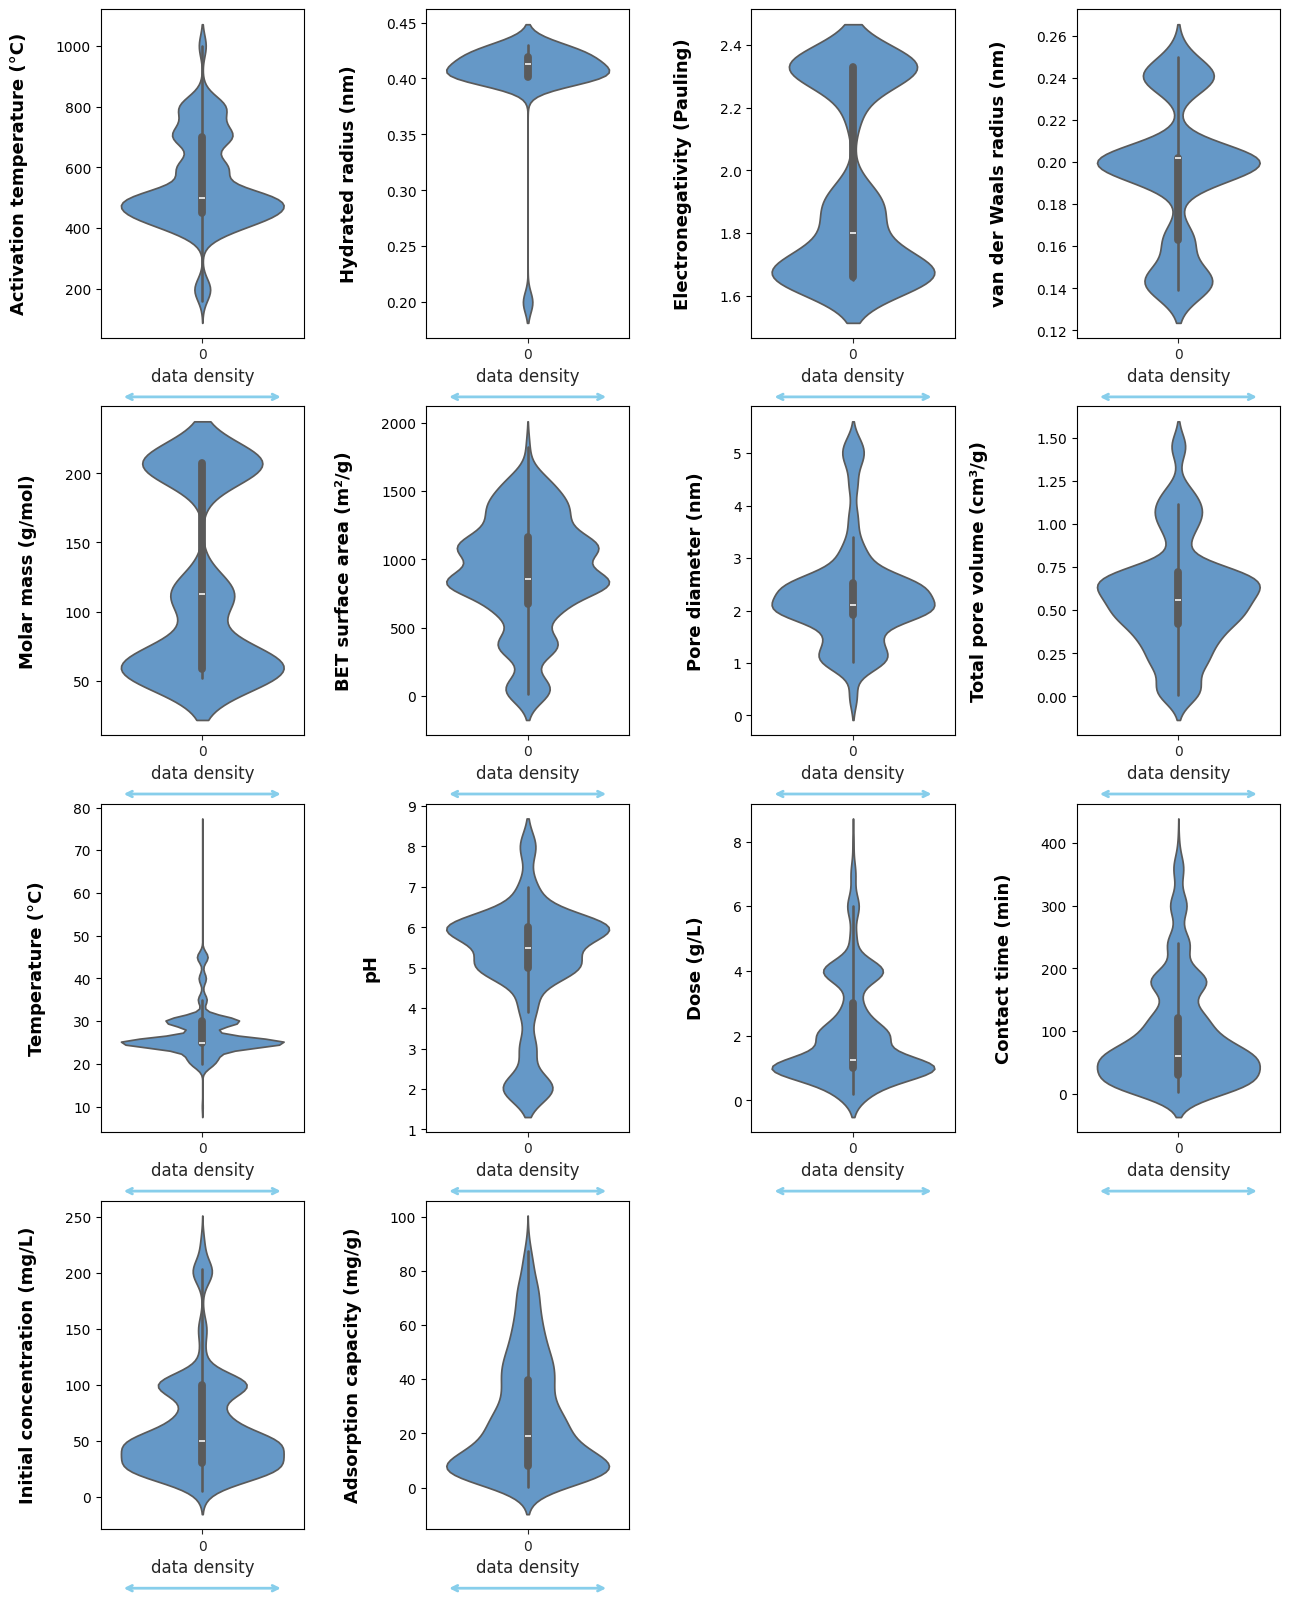

In [ ]:
# 7. Visualizing the distribution of variables
     # 7.1. Selecting numeric columns
cols = [col for col in data.select_dtypes(include='number').columns if col not in ['ID','Year']]

n_cols = 4
n_rows = -(-len(cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4*n_rows))
axes = axes.flatten()

sns.set_style("whitegrid")

for i, col in enumerate(cols):

    #  Violon VERTICAL normal
    sns.violinplot(
        y=data[col],
        ax=axes[i],
        color="#5599D7",
        inner="box"
    )

    # Label Y
    axes[i].set_ylabel(col, fontsize=13, rotation=90, labelpad=20, fontweight='bold')

    # Delete the main X-axis
    axes[i].set_xticks([])

    # Create a secondary X-axis for text
    ax2 = axes[i].secondary_xaxis("bottom")
    ax2.set_xticks([0])
    ax2.set_xticklabels(["0"])
    ax2.set_xlabel("data density", fontsize=12)

    #  Add the arrow to the MAIN axis
    axes[i].annotate(
        "",
        xy=(0.1, -0.18),
        xytext=(0.9, -0.18),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="<->", lw=2, color="skyblue")
    )

# Remove empty cells
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

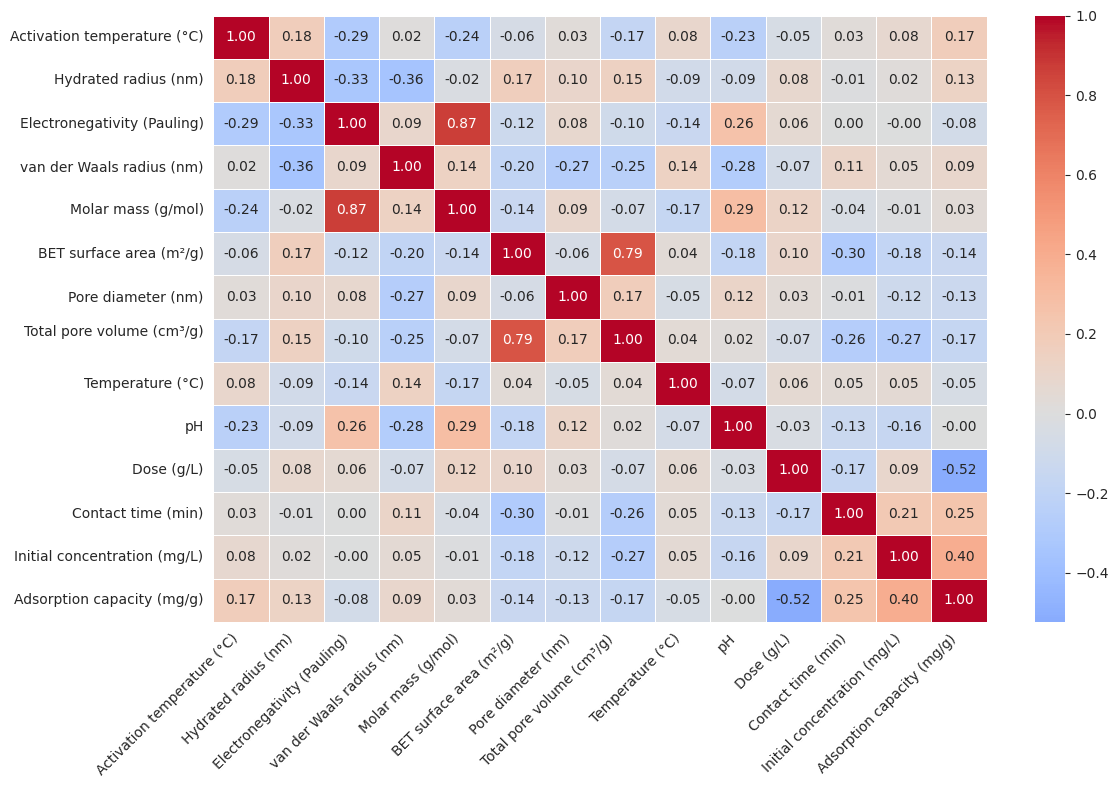

In [ ]:
# 8. Correlation analysis of numerical variables (heatmap)
     #  Selecting numeric columns
data_num = data.select_dtypes(include='number').drop(columns=['ID', 'Reference', 'Year', 'Adsorbent', 'Source of the adsorbent', 'Adsorbent code', 'Heavy metal'], errors='ignore')

     #  Calculation of the correlation matrix
corr = data_num.corr()

     # Heatmap Plot
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)

     # plt.title(" Correlation matrix ", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 9. Define numerical and categorical columns
numerical_cols = ['Dose (g/L)','Initial concentration (mg/L)','Contact time (min)', 'pH','BET surface area (m²/g)',
                  'Pore diameter (nm)','Total pore volume (cm³/g)\n',"Activation temperature (°C)",
                  'van der Waals radius (nm)','Temperature (°C)','Molar mass (g/mol)','Hydrated radius (nm)',
                 'Electronegativity (Pauling)'

       ]

In [ ]:
# 10. Definition of input and output variables
x = data[numerical_cols]
y = data['Adsorption capacity (mg/g)']

In [ ]:
# 11. Splitting the data into training, validation, and test sets
      # Create bins once
y_bins = pd.qcut(y, q=29, labels=False, duplicates='drop')

      # Split 1️ : Train (70%) AND Temp (30%)
x_train, x_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    x, y, y_bins, test_size=0.30, random_state=42, stratify=y_bins
)

      # Split 2️ : Temp : Validation (15%) AND Test (15%)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=bins_temp
)

In [ ]:
x_train.shape, x_val.shape, x_test.shape
y_train.shape, y_val.shape, y_test.shape

((1069,), (229,), (230,))

In [ ]:
# 12. Percentage of each metal in the train, validation, and testing

      # Retrieve the metal column from the indexes of each subassembly
metal_train = data.loc[x_train.index, 'Heavy metal']
metal_val   = data.loc[x_val.index, 'Heavy metal']
metal_test  = data.loc[x_test.index, 'Heavy metal']

      # Calculating percentages
pct_train = metal_train.value_counts(normalize=True).sort_index() * 100
pct_val   = metal_val.value_counts(normalize=True).sort_index() * 100
pct_test  = metal_test.value_counts(normalize=True).sort_index() * 100
pct_full  = data['Heavy metal'].value_counts(normalize=True).sort_index() * 100

      # Summary table
table_pct = pd.concat([pct_full, pct_train, pct_val, pct_test], axis=1)
table_pct.columns = ['Full %', 'Train %', 'Validation %', 'Test %']
table_pct = table_pct.fillna(0).round(2)

print(table_pct)

             Full %  Train %  Validation %  Test %
Heavy metal                                       
As(V)          3.47     3.55          3.06    3.48
Cd(II)        17.34    17.40         17.90   16.52
Cr(VI)        18.00    18.15         18.78   16.52
Cu(II)        12.70    12.63         13.54   12.17
Ni(II)         8.18     8.98          7.86    4.78
Pb(II)        33.25    32.55         31.88   37.83
Zn(II)         7.07     6.74          6.99    8.70


In [ ]:
# 13. Development, Training and Comparative Evaluation of Machine Learning Models

      # PREPROCESSING
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='drop'
)

      # EVALUATION FUNCTION
def evaluer(y_true, y_pred, nom):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n {nom} : RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.4f}")
    return rmse, mae, r2


      # CONVERSION (IMPORTANT FOR XGB AND GBR)
X_train_prep = preprocessor.fit_transform(x_train)
X_val_prep   = preprocessor.transform(x_val)
X_test_prep  = preprocessor.transform(x_test)


     # MODELS
models = {

    "RF": RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=0.9,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),

    "ET": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=25,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=0.9,
        max_samples=0.9,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),

    # GBR with internal early stopping
    "GBR": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.10,
        max_depth=15,
        subsample=0.7,
        max_features=0.7,
        min_samples_split=10,
        min_samples_leaf=6,
        loss='squared_error',
        random_state=42,
        validation_fraction=0.15,
        n_iter_no_change=20,
        tol=0.001,
        verbose=1
    ),

    # XGB with internal early stopping
    "XGB": XGBRegressor(
        objective='reg:squarederror',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=10,
        min_child_weight=7,
        gamma=5,
        subsample=0.7,
        colsample_bytree=1,
        reg_alpha=10,
        reg_lambda=30,
        random_state=42,
        early_stopping_rounds=30,
        eval_metric='rmse',
        n_jobs=-1
    )
}
      # dictionaries for storing predictions
train_predictions = {}
test_predictions = {}

      # TRAINING AND EVALUATION
results = []

for name, model in models.items():

    print("\n" + "="*70)
    print(f" Modèle : {name}")
    print("="*70)


    #  XGB (early termination with external validation)
    if name == "XGB":

        model.fit(
            X_train_prep, y_train,
            eval_set=[(X_train_prep, y_train), (X_val_prep, y_val)],
            verbose=True
        )

        y_train_pred = model.predict(X_train_prep)
        y_val_pred   = model.predict(X_val_prep)
        y_test_pred  = model.predict(X_test_prep)

    #  GBR (early stopping interne)
    else:
        pipe = Pipeline([
            ('preprocessing', preprocessor),
            ('model', model)
        ])

        pipe.fit(x_train, y_train)

        y_train_pred = pipe.predict(x_train)
        y_val_pred   = pipe.predict(x_val)
        y_test_pred  = pipe.predict(x_test)

    #  EVALUATION
    train_rmse, train_mae, train_r2 = evaluer(y_train, y_train_pred, f"{name} TRAIN")
    val_rmse, val_mae, val_r2       = evaluer(y_val, y_val_pred, f"{name} VALIDATION")
    test_rmse, test_mae, test_r2    = evaluer(y_test, y_test_pred, f"{name} TEST")

    results.append({
        "Model": name,
        "Train_R2": train_r2,
        "Val_R2": val_r2,
        "Test_R2": test_r2,
        "Test_RMSE": test_rmse
    })
# storage of training and test predictions
    train_predictions[name] = y_train_pred
    test_predictions[name]  = y_test_pred
    # FINAL TABLE
results_df = pd.DataFrame(results).sort_values(by="Test_R2", ascending=False)

print("\n Final results :")
print(results_df)


 Modèle : RF

 RF TRAIN : RMSE=2.525 | MAE=1.309 | R²=0.9864

 RF VALIDATION : RMSE=4.892 | MAE=2.408 | R²=0.9477

 RF TEST : RMSE=4.159 | MAE=2.258 | R²=0.9626

 Modèle : ET

 ET TRAIN : RMSE=2.380 | MAE=1.124 | R²=0.9879

 ET VALIDATION : RMSE=4.666 | MAE=2.202 | R²=0.9525

 ET TEST : RMSE=4.173 | MAE=2.078 | R²=0.9624

 Modèle : GBR
      Iter       Train Loss      OOB Improve   Remaining Time 
         1         382.9330          77.2560            1.90s
         2         341.7281         122.5903            1.17s
         3         292.4913          62.2780            0.89s
         4         233.8813          11.3529            0.75s
         5         192.7774          21.6046            0.66s
         6         171.3389          48.6411            0.60s
         7         148.2827          30.7963            0.56s
         8         122.8077           6.6354            0.53s
         9         105.6970          15.8670            0.51s
        10          98.7911          31.

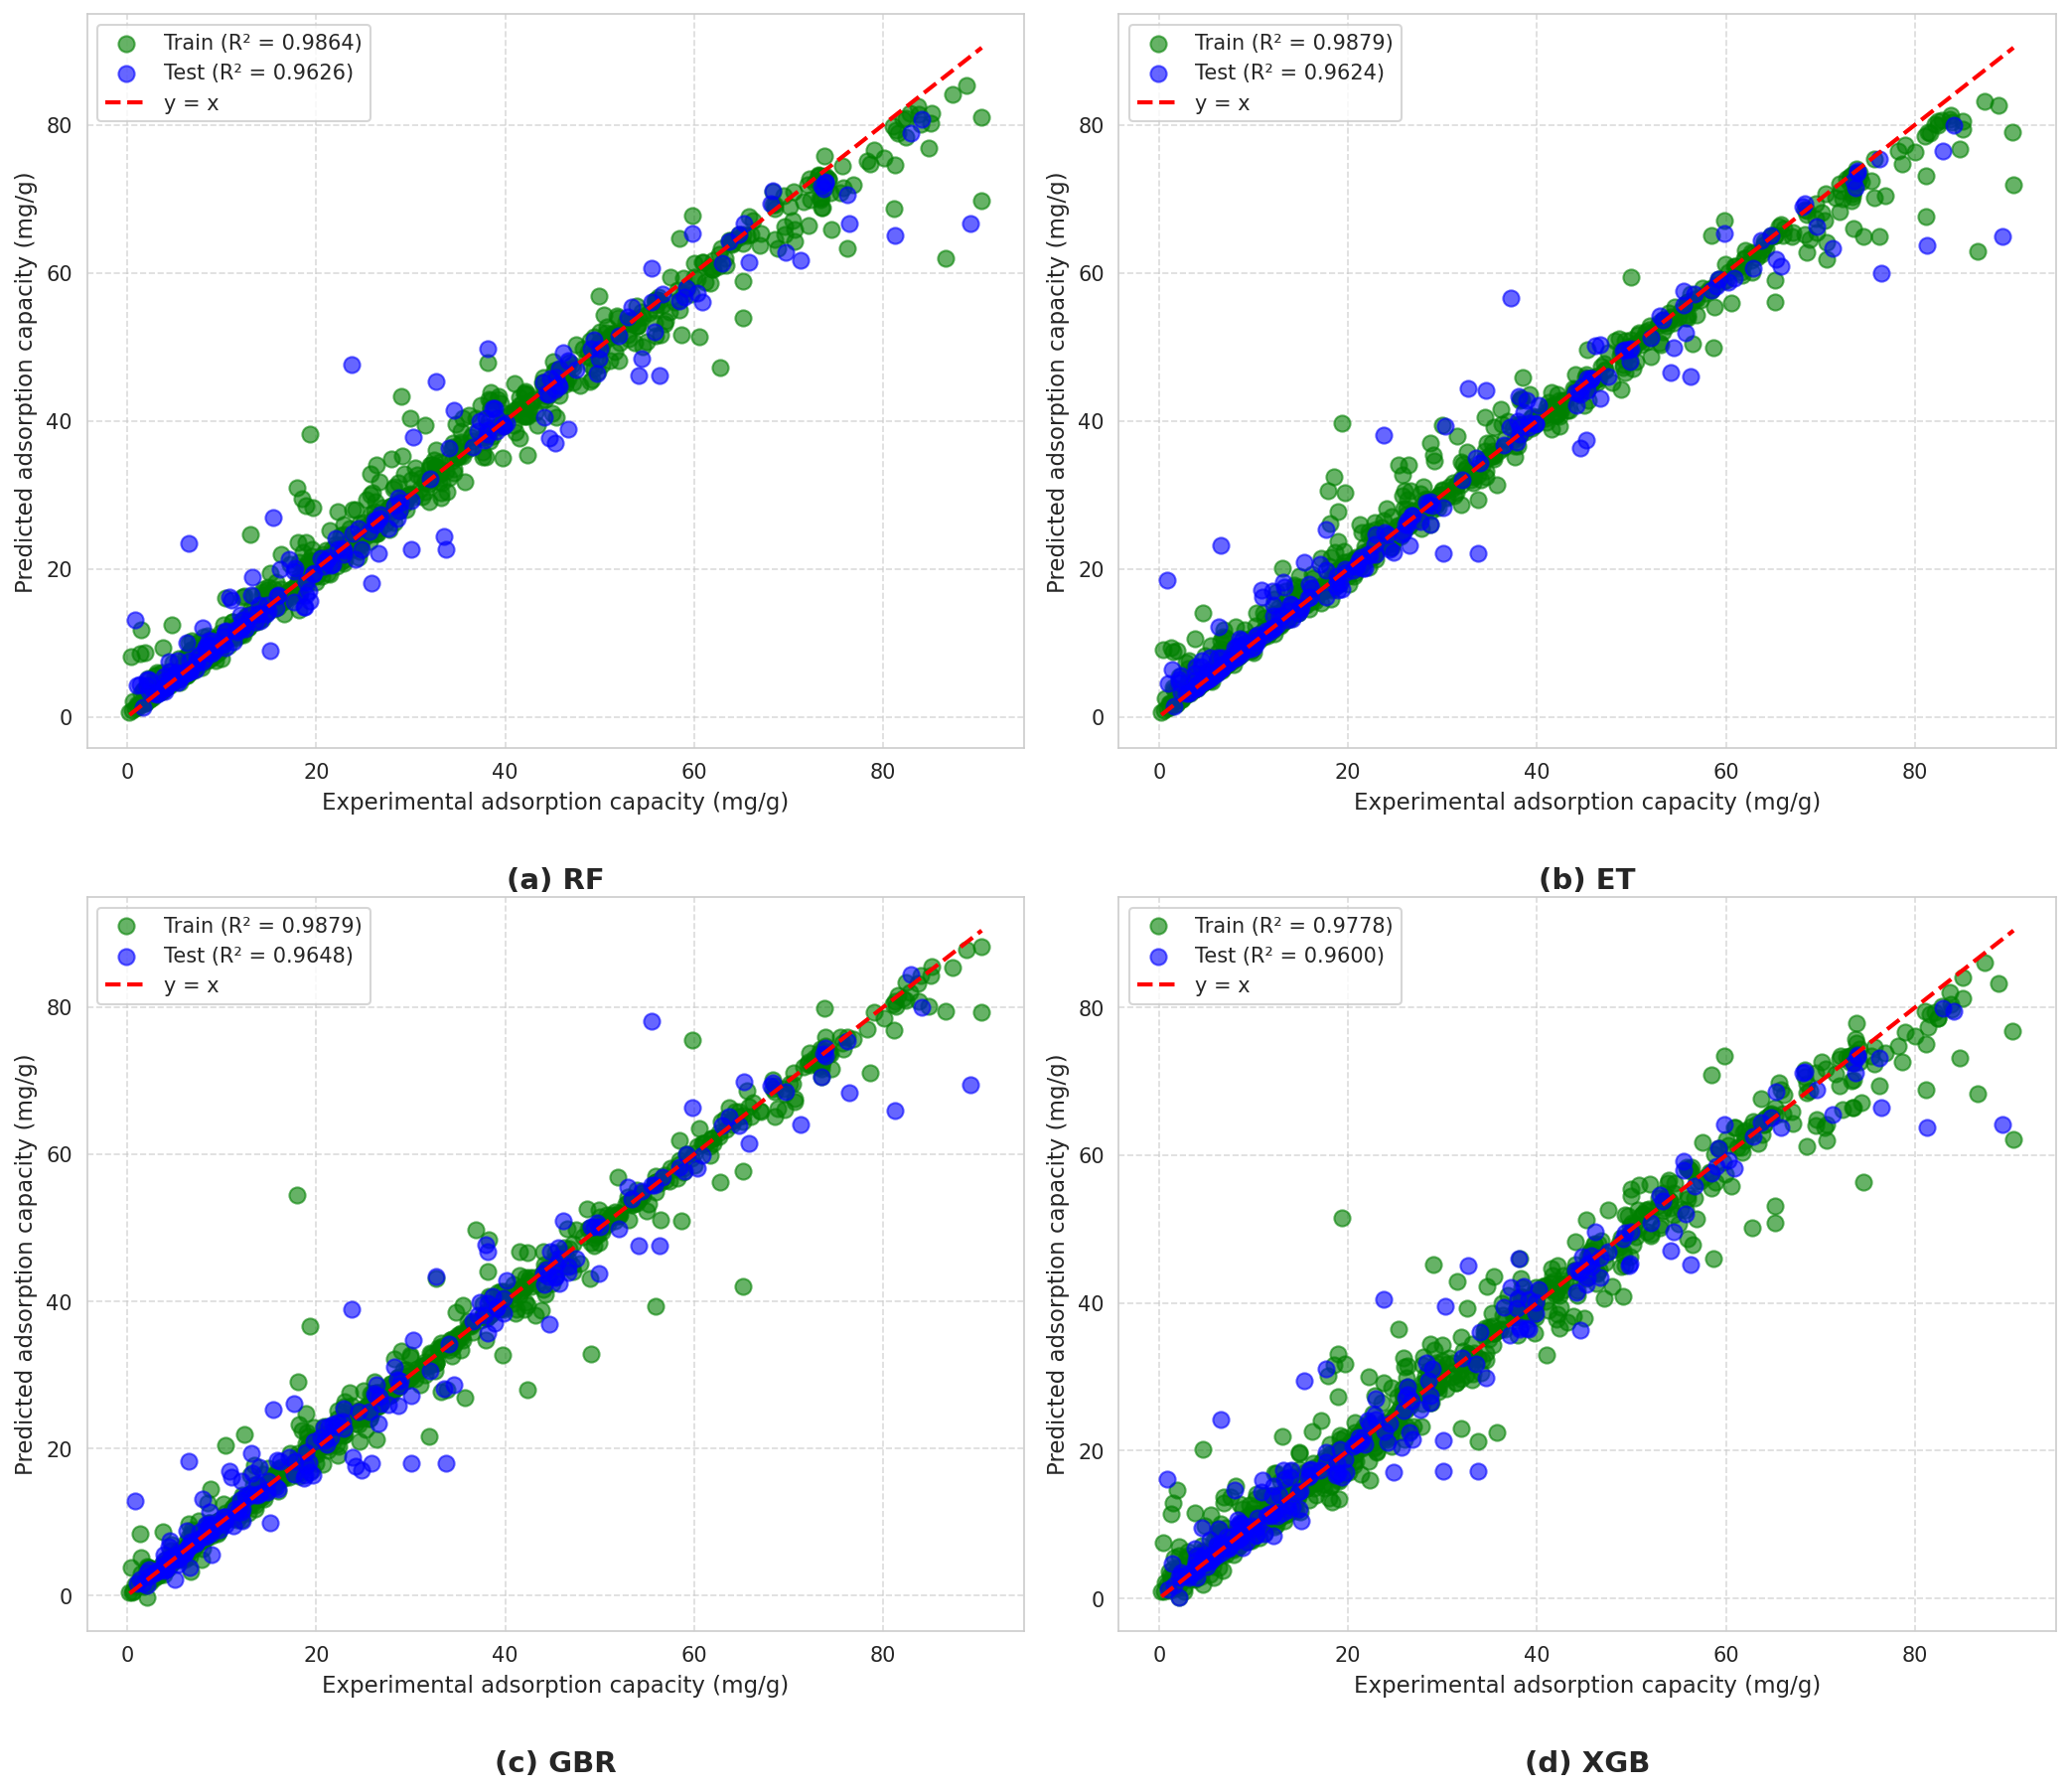

In [ ]:
# 14. Actual vs Predicted

fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=150)
axes = axes.flatten()

panel_labels = {
    "RF": "(a) RF",
    "ET": "(b) ET",
    "GBR": "(c) GBR",
    "XGB": "(d) XGB"
}

for i, name in enumerate(models.keys()):

    y_train_pred = train_predictions[name]
    y_test_pred  = test_predictions[name]

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test  = r2_score(y_test, y_test_pred)

    # Limitations
    min_val = min(y_test.min(), y_train.min())
    max_val = max(y_test.max(), y_train.max())

    # TRAIN (green)
    axes[i].scatter(
        y_train, y_train_pred,
        color='green',
        alpha=0.6, s=60,
        label=f'Train (R² = {r2_train:.4f})'
    )

    # TEST (blue)
    axes[i].scatter(
        y_test, y_test_pred,
        color='blue',
        alpha=0.6, s=60,
        label=f'Test (R² = {r2_test:.4f})'
    )

    # Ideal line (x=y)
    axes[i].plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--', lw=2,
        label='y = x'
    )

    # Labels
    axes[i].set_xlabel('Experimental adsorption capacity (mg/g)', fontsize=11)
    axes[i].set_ylabel('Predicted adsorption capacity (mg/g)', fontsize=11)

    # Style
    axes[i].legend(loc='upper left', fontsize=10, frameon=True)
    axes[i].grid(True, linestyle='--', alpha=0.7)

    # Label (a)(b)(c)(d)
    axes[i].text(
        0.5, -0.18,
        panel_labels[name],
        transform=axes[i].transAxes,
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

 Metrics - Training set
         R²     EVS    RMSE     MAE     MAPE     RSR
RF   0.9864  0.9864  2.5245  1.3093  11.1041  0.1165
ET   0.9879  0.9880  2.3802  1.1241  10.8249  0.1098
GBR  0.9879  0.9879  2.3863  0.9765   7.3047  0.1101
XGB  0.9778  0.9778  3.2297  1.7904  15.8327  0.1490

 Metrics - Testing set
         R²     EVS    RMSE     MAE     MAPE     RSR
RF   0.9626  0.9626  4.1591  2.2581  20.7147  0.1933
ET   0.9624  0.9625  4.1728  2.0783  23.7833  0.1940
GBR  0.9648  0.9648  4.0349  2.2049  17.7528  0.1876
XGB  0.9600  0.9600  4.3029  2.4109  22.2674  0.2000


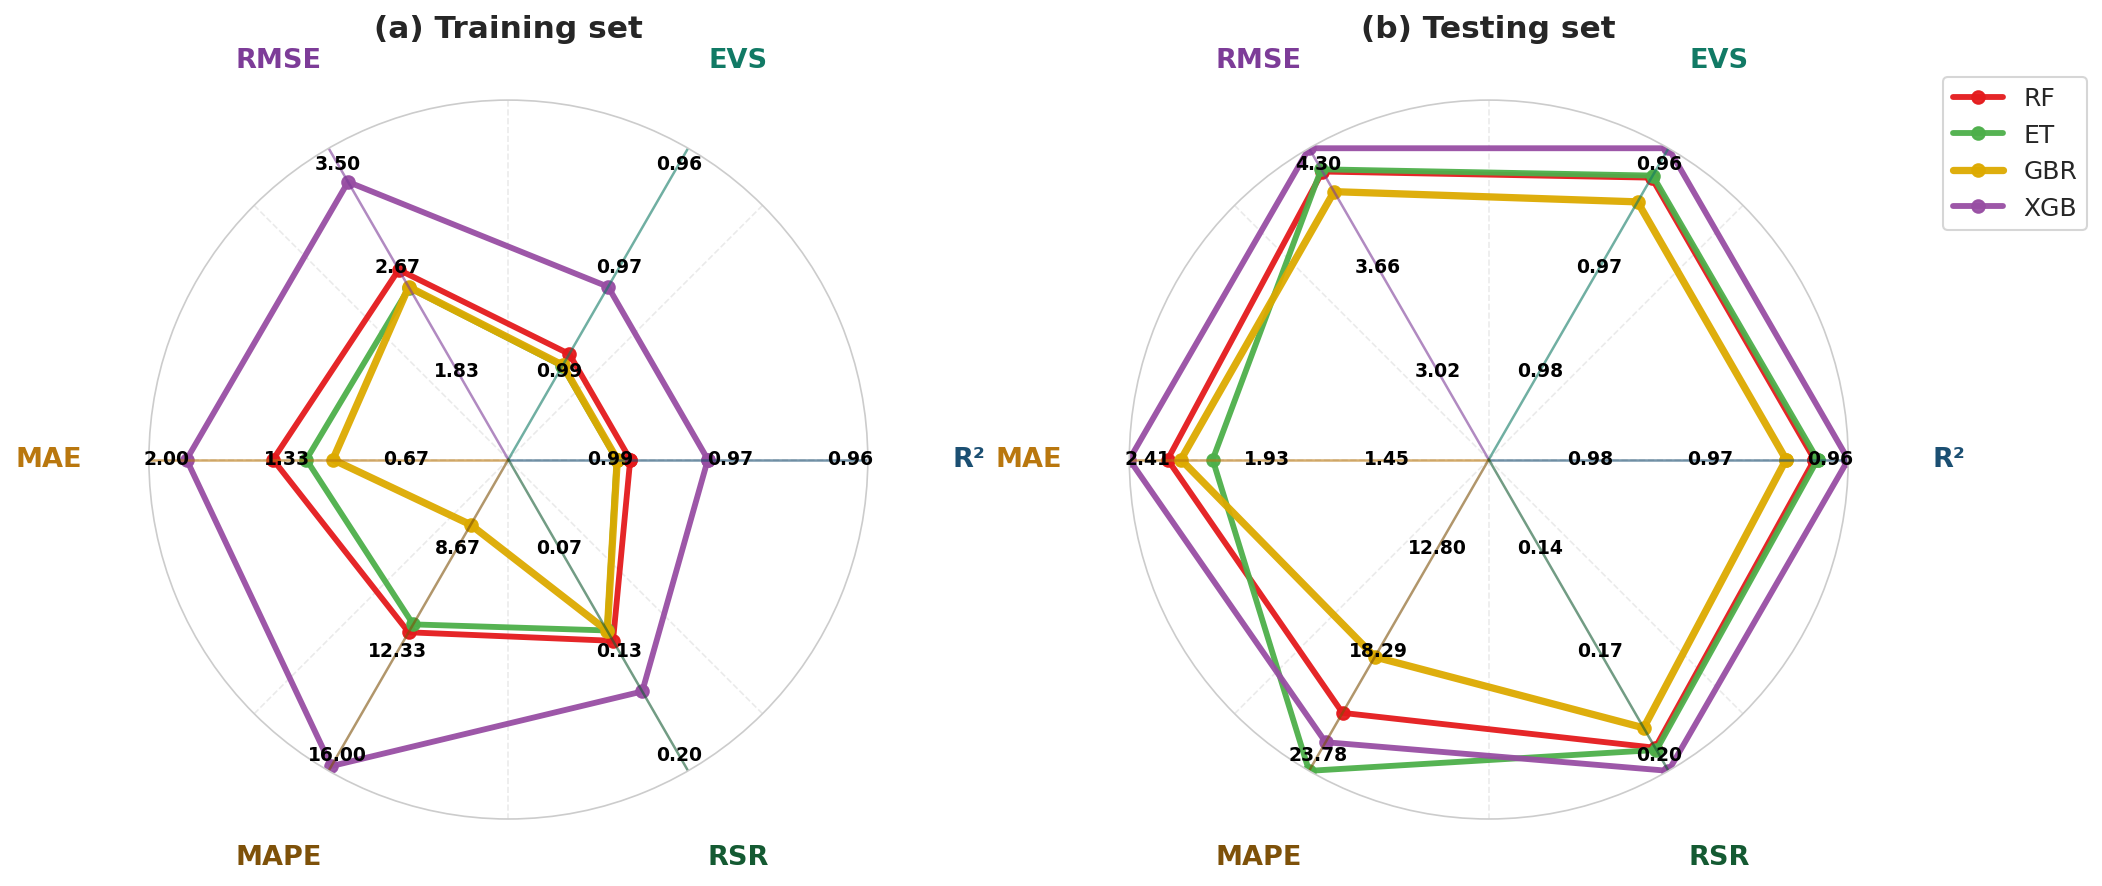

In [ ]:
# 15. Radar chart

      #  FUNCTION FOR CALCULATING METRICS
def calculer_metriques(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rsr = rmse / np.std(y_true)
    return [r2, evs, rmse, mae, mape, rsr]

      # evaluation models and metrics
models_list = ['RF', 'ET', 'GBR', 'XGB']
metrics = ['R²', 'EVS', 'RMSE', 'MAE', 'MAPE', 'RSR']

      #  CALCULATION OF METRICS
train = np.array([
    calculer_metriques(y_train, train_predictions['RF']),
    calculer_metriques(y_train, train_predictions['ET']),
    calculer_metriques(y_train, train_predictions['GBR']),
    calculer_metriques(y_train, train_predictions['XGB'])
])

test = np.array([
    calculer_metriques(y_test, test_predictions['RF']),
    calculer_metriques(y_test, test_predictions['ET']),
    calculer_metriques(y_test, test_predictions['GBR']),
    calculer_metriques(y_test, test_predictions['XGB'])
])

          # SUMMARY TABLES
df_train = pd.DataFrame(train, index=models_list, columns=metrics).round(4)
df_test = pd.DataFrame(test, index=models_list, columns=metrics).round(4)

print(" Metrics - Training set")
print(df_train)

print("\n Metrics - Testing set")
print(df_test)

           #  colors
colors = {
    'RF':   '#E41A1C',
    'ET':   '#4DAF4A',
    'GBR':  '#DDAA00',
    'XGB':  '#984EA3'
}

axis_colors = ['#1B4F72', '#117A65', '#7D3C98', '#B9770E', '#7E5109', '#145A32']

          #  NORMALISATION
def normalize_dataset(data, mins, maxs):
    norm = np.zeros_like(data, dtype=float)

    for j, m in enumerate(metrics):
        norm[:, j] = (data[:, j] - mins[j]) / (maxs[j] - mins[j])
        norm[:, j] = np.clip(norm[:, j], 0, 1)

          # reversal
        if m in ['R²', 'EVS']:
            norm[:, j] = 1 - norm[:, j]

    return norm

      # Custom terminals for TRAIN
train_min = np.array([0.96, 0.96, 1.0, 0.0, 5.0, 0.0])
train_max = np.array([1.00, 1.00, 3.5, 2.0, 16.0, 0.2])

      # Global variables for TEST
global_min = np.minimum(train.min(axis=0), test.min(axis=0))
global_max = np.maximum(train.max(axis=0), test.max(axis=0))

      # Normalisation
train_norm = normalize_dataset(train, train_min, train_max)
test_norm = normalize_dataset(test, global_min, global_max)

      # PLOT RADAR FUNCTION
def radar_plot(ax, data, title, mins, maxs):
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

      # Draw the main lines
    for i, model in enumerate(models_list):
        values = data[i].tolist()
        values += values[:1]

        lw = 3.5 if model == 'GBR' else 2.8

        ax.plot(
            angles,
            values,
            color=colors[model],
            lw=lw,
            marker='o',
            markersize=6,
            label=model,
            alpha=0.95
        )

         #  Colored axes
    for i, color in enumerate(axis_colors):
        ax.plot([angles[i], angles[i]], [0, 1], color=color, lw=1.2, alpha=0.6)

         # Metric labels
    for i, label in enumerate(metrics):
        angle_rad = angles[i]
        ax.text(
            angle_rad,
            1.28,
            label,
            fontsize=13,
            fontweight='bold',
            color=axis_colors[i],
            ha='center',
            va='center'
        )

        # Actual graduations
    for i, m in enumerate(metrics):
        rad = angles[i]
        tick_vals = np.linspace(mins[i], maxs[i], 4)

        for t in tick_vals:
            r = (t - mins[i]) / (maxs[i] - mins[i])

            if m in ['R²', 'EVS']:
                r = 1 - r

            ax.text(
                rad,
                r - 0.05,
                f"{t:.2f}",
                fontsize=9,
                fontweight='bold',
                color='black',
                ha='center',
                va='center'
            )

         # Overall style
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=30)

       #  FINAL FIGURE
fig, axes = plt.subplots(
    1, 2,
    subplot_kw=dict(polar=True),
    figsize=(14, 6),
    dpi=150
)

fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_xticklabels([])

radar_plot(axes[0], train_norm, "(a) Training set", train_min, train_max)
radar_plot(axes[1], test_norm, "(b) Testing set", global_min, global_max)

plt.legend(models_list, loc='upper right', bbox_to_anchor=(1.35, 1.05), fontsize=12)
plt.tight_layout()
plt.show()

 97%|=================== | 1481/1528 [00:32<00:01]       

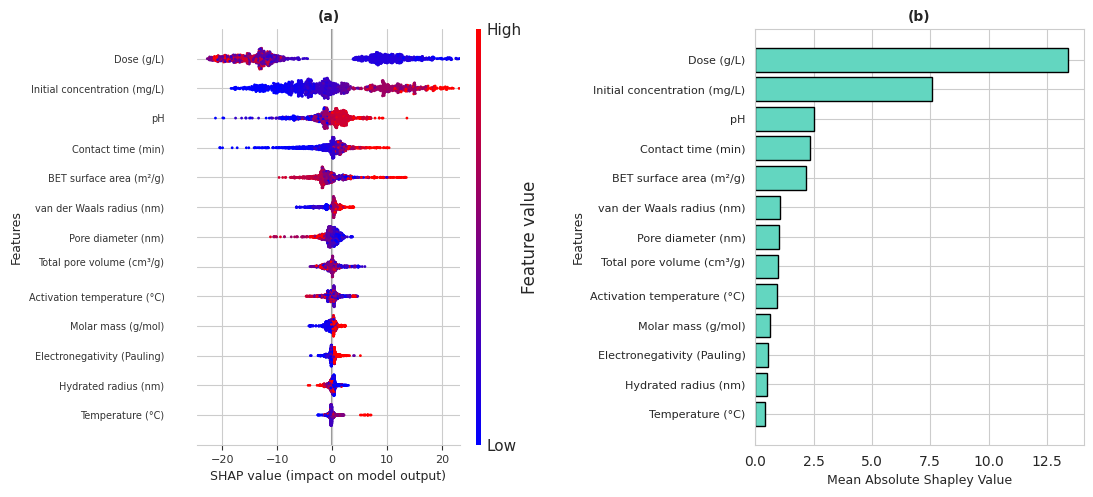

In [ ]:
# 16. Model Interpretation Using SHAP

numerical_cols = [
    'Dose (g/L)',
    'Initial concentration (mg/L)',
    'Contact time (min)',
    'pH',
    'BET surface area (m²/g)',
    'Pore diameter (nm)',
    'Total pore volume (cm³/g)\n',
    'Activation temperature (°C)',
    'van der Waals radius (nm)',
    'Temperature (°C)',
    'Molar mass (g/mol)',
    'Hydrated radius (nm)',
    'Electronegativity (Pauling)'
]

       # TAKE ADVANTAGE OF THE ALREADY ESTABLISHED PIPELINE
model = pipe.named_steps['model']

       # processed data
x_scaled = pipe.named_steps['preprocessing'].transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=numerical_cols, index=x.index)

       # SHAP
explainer = shap.Explainer(model, x_scaled)
shap_values = explainer(x_scaled, check_additivity=False)

       # FIGURE
two_color_cmap = LinearSegmentedColormap.from_list(
    "red_blue", ["blue", "red"], N=256
)

plt.figure(figsize=(16, 6))
shap_min = np.percentile(shap_values.values, 1)
shap_max = np.percentile(shap_values.values, 99)
margin = (shap_max - shap_min) * 0.2

      # (a) SHAP summary plot
plt.subplot(1, 2, 1)
plt.rcParams['scatter.marker'] = '.'
plt.rcParams['lines.markersize'] = 3

shap.summary_plot(shap_values.values, x_scaled, show=False, plot_size=(12, 5), cmap=two_color_cmap, color_bar=True
)

plt.xlim(shap_min - margin, shap_max + margin)
plt.title("(a)", fontsize=10, fontweight='bold')
plt.xlabel("SHAP value (impact on model output)", fontsize=9)
plt.ylabel("Features", fontsize=9)
plt.tick_params(axis='y', labelsize=7)
plt.tick_params(axis='x', labelsize=8)

# (b) Mean absolute SHAP
plt.subplot(1, 2, 2)
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
indices = np.argsort(mean_abs_shap)

plt.barh(
    range(len(numerical_cols)),
    mean_abs_shap[indices],
    color="#63D6C0",
    edgecolor='black'
)

plt.yticks(range(len(numerical_cols)), np.array(numerical_cols)[indices], fontsize=8)
plt.xlabel("Mean Absolute Shapley Value", fontsize=9)
plt.ylabel("Features", fontsize=9)
plt.title("(b)", fontsize=10, fontweight='bold')

plt.subplots_adjust(wspace=0.7)
plt.show()

 Top variables for DPD : ['Dose (g/L)', 'Initial concentration (mg/L)', 'BET surface area (m²/g)', 'pH', 'Contact time (min)', 'Total pore volume (cm³/g)\n', 'Pore diameter (nm)', 'Activation temperature (°C)', 'van der Waals radius (nm)', 'Molar mass (g/mol)', 'Hydrated radius (nm)', 'Temperature (°C)', 'Electronegativity (Pauling)']


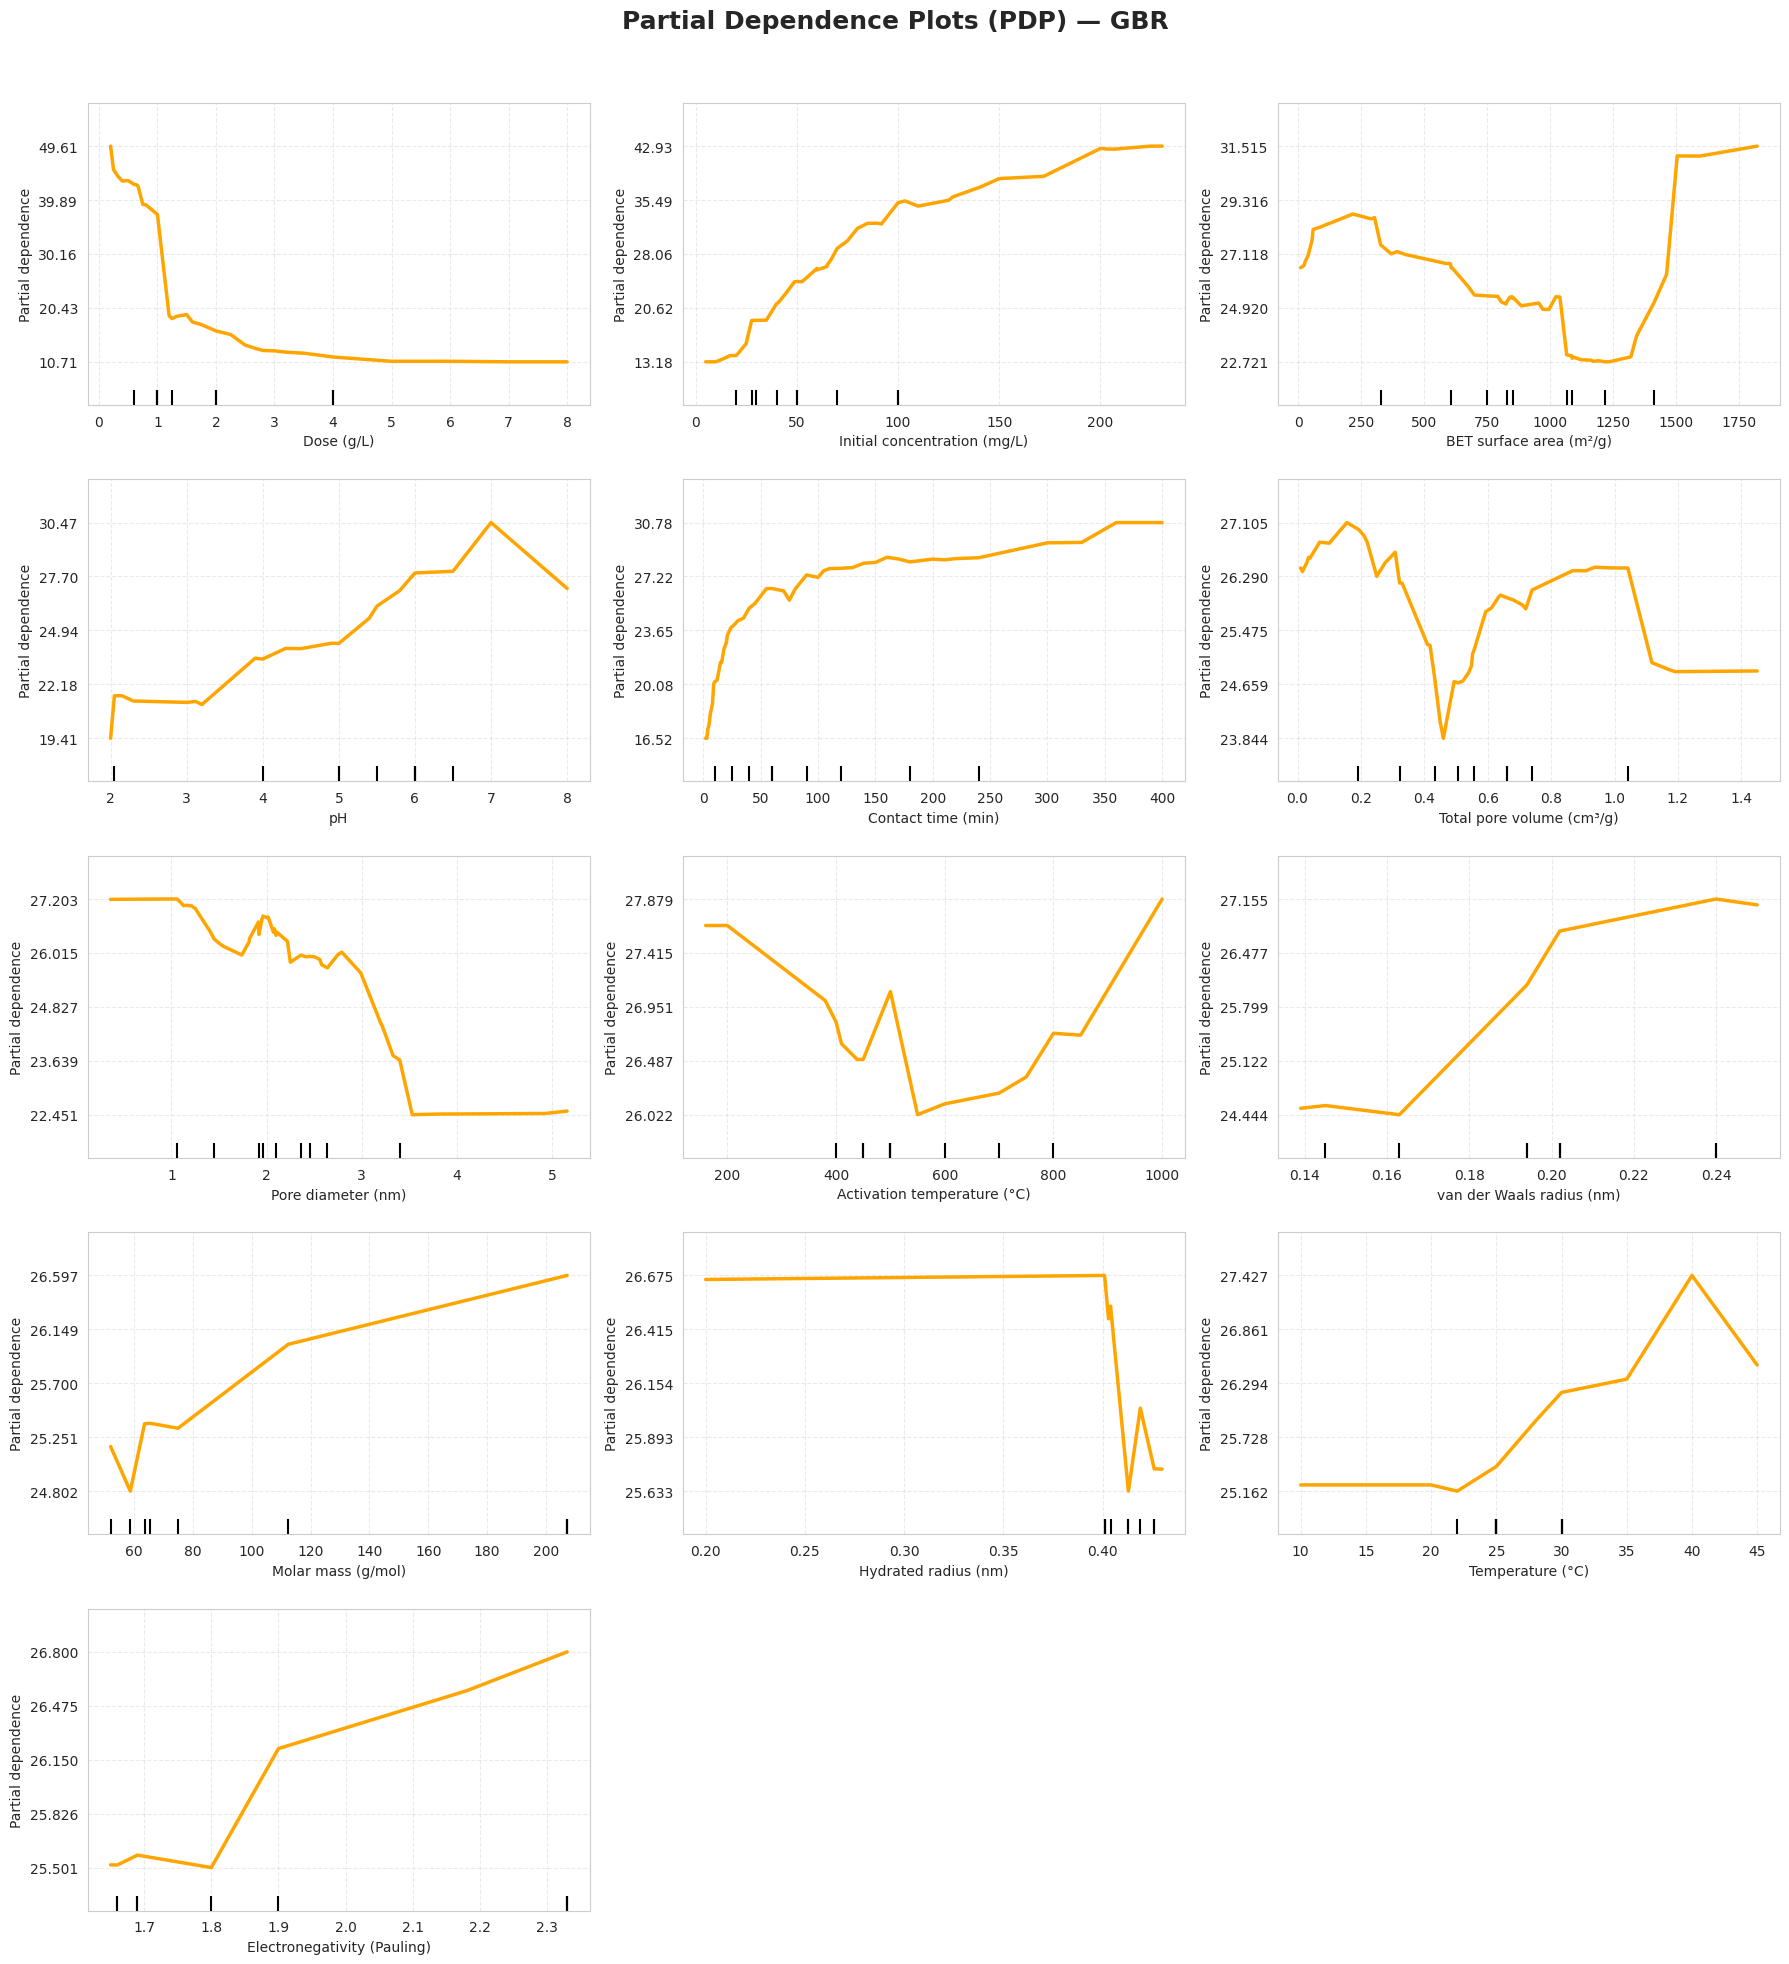

In [ ]:
# 17. Partial Dependence Plots-(PDP)-GBR

      # ROECOVER THE PRE-TRAINED GBR PIPELINE
gbr_pipe = pipe

      # DOWNLOAD THE GBR TEMPLATE
gbr_model = gbr_pipe.named_steps['model']
      # SELECT THE MOST IMPORTANT VARIABLES

      # Determine the significance of the variables
importances = gbr_model.feature_importances_
feat_imp = pd.DataFrame({
    'Variable': numerical_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

      # SELECT THE MOST IMPORTANT VARIABLES
top_features = feat_imp['Variable'].head(13).tolist()
print(" Top variables for DPD :", top_features)
      # CREATE THE SUBPLOT GRID
n_features = len(top_features)
cols = 3
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()
      #  DRAWING THE PDPs
display = PartialDependenceDisplay.from_estimator( estimator=gbr_pipe, X=x_train, features=top_features, ax=axes[:n_features],
    grid_resolution=100,kind='average', line_kw={"color": "orange", "linewidth": 2.5}
)


      #  ADJUST THE Y-AXES AFTER PLOTTING
for i, axe in enumerate(display.axes_.ravel()):
    lignes = axe.get_lines()

    if len(lignes) > 0:
        y_data = lignes[0].get_ydata()
        y_min, y_max = np.min(y_data), np.max(y_data)

        # avoid problems if the curve is nearly flat
        if y_max - y_min == 0:
            marge = 0.1
        else:
            marge = (y_max - y_min) * 0.20

        axe.set_ylim(y_min - marge, y_max + marge)
        axe.set_yticks(np.linspace(y_min, y_max, 5))

    axe.grid(True, linestyle="--", alpha=0.4)
    axe.tick_params(axis='both', labelsize=10)

         # REMOVE EMPTY CELLS
for j in range(n_features, rows * cols):
    fig.delaxes(axes[j])

         #  FINAL TITLE
plt.suptitle(
    "Partial Dependence Plots (PDP) — GBR",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()